# Set up

In [37]:
from pathlib import Path
from typing import Optional, Dict, Tuple, Any
from dataclasses import dataclass
from datetime import datetime

from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives.asymmetric.types import PrivateKeyTypes
from pycose.messages.sign1message import Sign1Message
from pycose.keys.cosekey import CoseKey
from pycose.headers import Algorithm
from pycose.algorithms import EdDSA
from pycose.keys.curves import Ed25519
from pycose.keys.keyparam import KpKty, OKPKpD, OKPKpX, KpAlg, KpKeyOps, OKPKpCurve
from pycose.keys.keytype import KtyOKP
from pycose.keys.keyops import SignOp, VerifyOp
from pyzbar.pyzbar import decode
from PIL import Image
import cbor2
import zlib

import base64
import base45
import qrcode
from io import BytesIO
from pprint import pprint

In [ ]:
PRIVATE_KEY_PATH = Path(r"./private_key.pem")
PRIVATE_KEY_PASSWORD = b"password"

def _load_pem_private_key(                  # pylint: disable=missing-function-docstring
    key_path : Path,
    password : Optional[bytes] = None
) -> PrivateKeyTypes :
    if not key_path.exists():
        raise FileNotFoundError(f"Private key not found at {key_path}")
    
    with open(key_path, "rb") as key:
        return serialization.load_pem_private_key(
            key.read(),
            password=password
        )


def _load_eddsa_key(
        path_to_key : Path, password : bytes
    ) -> CoseKey :          # pylint: disable=missing-function-docstring
    private_key = _load_pem_private_key(path_to_key, password)
    private_bytes = private_key.private_bytes(
        encoding=serialization.Encoding.Raw,
        format=serialization.PrivateFormat.Raw,
        encryption_algorithm=serialization.NoEncryption()
    )
    
    public_key = private_key.public_key()
    public_bytes = public_key.public_bytes(
        encoding=serialization.Encoding.Raw,
        format=serialization.PublicFormat.Raw
    )
    
    cose_key = {
        KpKty: KtyOKP,
        KpAlg: EdDSA,
        OKPKpCurve: Ed25519,
        KpKeyOps: [SignOp, VerifyOp],
        OKPKpD: private_bytes,
        OKPKpX: public_bytes
    }

    return CoseKey.from_dict(cose_key)

# Generating Signed QR

## Generate Face Bytes

In [ ]:
IMG = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\residents\sample\output.png"

with open(IMG, "rb") as file:
    image_bytes = file.read()

In [ ]:
data = {
    "id" : 4,
    "pcn"  : 6149804723,
    "issued_at" : datetime.now().strftime("d-m-Y"),
    "verified" : True,
    "email" : "jtgeraldo@up.edu.ph",
    "phone_number" : "09760406460",
    "face_data" : image_bytes,
}

cose_key = _load_eddsa_key(PRIVATE_KEY_PATH, PRIVATE_KEY_PASSWORD)

payload = cbor2.dumps(data)

sign1_message = Sign1Message(
    phdr={ Algorithm: EdDSA },
    payload=payload
)
sign1_message.key = cose_key

signed_message = sign1_message.encode()

compressed = zlib.compress(signed_message)

qr_b45 = base45.b45encode(compressed).decode()

qr = qrcode.make(qr_b45)

buffer = BytesIO()
qr.save(buffer, format="PNG")
buffer.seek(0)

qr


# Reading and Verifying of Signed QR

In [50]:
file = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\residents\sample\with face\QR_RealTampered.png"

decoded_text = decode(Image.open(file))[0].data.decode('utf-8')
decoded_text

'6BFC90Z70T9WJWG.FKJ05FBBC$A%JC:SCVPCTPCRI300068031ITUM+ED$QE  CR2C7WE+TC4 DSDBO/E*KER.C  C11V0$C7EC/VDRKD93DVKESVD+2E4%E.%5MVC8*529DL9E-3EV CH/DC$D5$CZODMA7C%6+Q6G%6C%6RED1ECV C2VC3WE$AB5IAZ*8VPS000L1BBH81-AD47J2R000JBMM30S600V50V5-08TQLR1CHYLK*K0$HAAIO81000Z.HK7R3JPL7FK8S/5BAG5D0B*E8:FFD.54-FUP52/P8MB423W%R2VU-SKSY1WNMG81A/L504PJGT50ZVH$WO%*9QPBWIHN%L3US5G01K5H1NUHBREQ:HET9HRUK13JU$21DTNJU E3TUR/5JK87/50D12G9VRI71ZO-91J2RYUE:ER0MU5 VF.SNHJGL6T4EN/7P/IPHI*8CY95FZHRWRG$E2P3P2VU*5RXBKBUYRD5%0VBPKOO3$9THA0LP5 CADQSJEOSGH%BA2H3EMM9744827BKXC5QEYNL92F. T-8EOKNCKB4CG UQDB4TM9DVSR+88L9GAI:LQ%WOV+9T$EMJQ*RN:%81NS84DL0I+$BWVT.KP2Q1-GKLP5Y.QM+M'

In [51]:
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
sign1_msg = Sign1Message.decode(uncompressed)

pprint(sign1_msg)
print("Unprotected Header bytes:", sign1_msg.uhdr_encoded)
print("Protected Header bytes:", sign1_msg.phdr_encoded)
print("Signature:", sign1_msg._signature)

<COSE_Sign1: [{'Algorithm': 'EdDSA'}, {}, b'\xa7bid\x04' ... (341 B), b'd\xcdsU\xaa' ... (64 B)]>
Unprotected Header bytes: {}
Protected Header bytes: b"\xa1\x01'"
Signature: b'd\xcdsU\xaaJw\n\xeb\xe3pO\xb9\x8bZ\x93\x80\xb0\xd3\x14!\xa0K,\xe2\xfcFkJ\xea\x904\xd1\x87\xc3\x9eNXu\\\xd1\x17\xba\xd5F"\xe1\x88g\x91\x8ew]\xac\xea\xf8\xc9o\x0c}\xa1-,\x07'


In [52]:
payload = cbor2.loads(sign1_msg.payload)
pprint(payload)

{'email': 'jtgeraldo@up.edu.ph',
 'face_data': b'RIFF\xe2\x00\x00\x00WEBPVP8 \xd6\x00\x00\x00\xb0\x08\x00\x9d'
              b'\x01*-\x00-\x00?q\xaa\xcc_4\xac(\xa5#\x8c\xfa\x90.\ti\x00\x00'
              b'\x8d\xfe\xd6\xe2\xc9\x1bw\xf7\xde\xf8X\x0f*gW\x10A\xe5yv'
              b'.\xfc}\xe0,\x10\xcdRZ\xe9\x18\x19\xdca\xf2\xc3\xa3I\r\xff'
              b'\xb21\ta\xad\xb6\x1f\xa9\x82\x00\x00\xfe\x8c\x0f\xc3\x9dN2[\x82'
              b'\x89\xc3\xac\xe2\xe2\xc5\x02\xd5+\x12\xb6-Z\x1e\xd0;q\xe7\x88+'
              b'\xa3\x95\x96\xd3\x16q\xe7\xaf\xf0\xbc\x1aU\xda\xf6\x97W'
              b'8\xdb\x01\x0c\x10\x0c\xf6\xdc:\xa4\xc4\x00\t\xa7\xd6\x00t&\xd85'
              b'\xf1,\xfb\x90\xe4\xed\x99_37o\x8f?\x05\x96\n\x91x`{)D\x8c\xaf'
              b'\xdbNuO\x1c"\xf5\xaa.\x86\\\xeb\xefQk\xb6\x06\xb3\xc7\xcf'
              b'\xc2$M\xb5R4\xc9reE\xcf\xfdr1\x83\x94]\xc2\x86\xdd\xb0\x7f9\n'
              b'@\x00',
 'id': 4,
 'issued_at': 'd-m-Y',
 'pcn': 6149804723,
 'phone_number': '09760406460',
 've

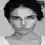

In [53]:
img = Image.open(BytesIO(payload["face_data"]))
img

# Tampering

## Read QR

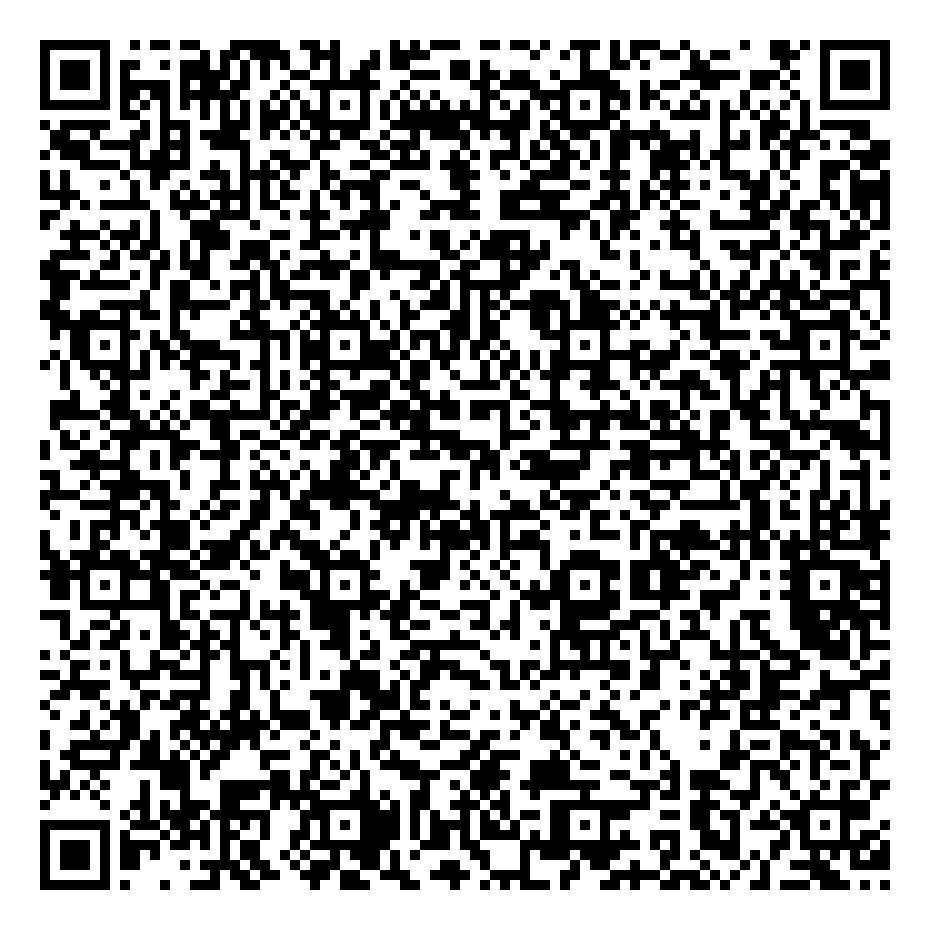

In [2]:
QR_PATH = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\residents\sample\with face\QR_Correct.png"
qr_img = Image.open(QR_PATH)
decoded_text = decode(qr_img)[0].data.decode('utf-8')
qr_img

## Decoding the message

In [10]:
payload_b45 = decoded_text
decoded_b45 = base45.b45decode(payload_b45)
decompressed = zlib.decompress(decoded_b45)
sign1_msg = Sign1Message.decode(decompressed)
payload = cbor2.loads(sign1_msg.payload)

print(sign1_msg)
pprint(payload)

<COSE_Sign1: [{'Algorithm': 'EdDSA'}, {}, b'\xa7bid\x04' ... (409 B), b'd\xcdsU\xaa' ... (64 B)]>
{'email': 'jtgeraldo@up.edu.ph',
 'face_data': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01'
              b'\x00\x01\x00\x00\xff\xdb\x00C\x00P7<F<2PFAFZUP_x\xc8\x82xn'
              b'nx\xf5\xaf\xb9\x91\xc8\xff\xff\xff\xff\xff\xff\xff\xff\xff'
              b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
              b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
              b'\xff\xff\xff\xff\xff\xff\xc0\x00\x0b\x08\x00-\x00-\x01\x01'
              b'\x11\x00\xff\xc4\x00\x19\x00\x00\x03\x01\x01\x01'
              b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02'
              b'\x03\x04\x00\x01\x05\xff\xc4\x00\x1f\x10\x00\x02'
              b'\x02\x02\x03\x00\x03\x00\x00\x00\x00\x00\x00\x00'
              b'\x00\x00\x01\x11\x00\x02\x03!\x121A\x042Q\xff\xda'
              b'\x00\x08\x01\x01\x00\x00?\x00*\x01La\xce\x1b\xd4\xfb'
              b'9\x06\xd6\x03\xb3\x07\

## Changing the Image

In [29]:
IMG = r"C:\Users\J4M3S\Desktop\MOSIP\philsys-qr-generator\sample_biometrics\sample.jpg"

buffer = BytesIO()

face_img = Image.open(IMG)
face_img_bw = face_img.convert("L")
face_img_resized = face_img_bw.resize((45, 45))

face_img_resized.save(buffer, format="WEBP", quality=10, optimize=True)
img_bytes = buffer.getvalue()

payload["face_data"] = img_bytes
pprint(payload)

{'email': 'jtgeraldo@up.edu.ph',
 'face_data': b'RIFF\xe2\x00\x00\x00WEBPVP8 \xd6\x00\x00\x00\xb0\x08\x00\x9d'
              b'\x01*-\x00-\x00?q\xaa\xcc_4\xac(\xa5#\x8c\xfa\x90.\ti\x00\x00'
              b'\x8d\xfe\xd6\xe2\xc9\x1bw\xf7\xde\xf8X\x0f*gW\x10A\xe5yv'
              b'.\xfc}\xe0,\x10\xcdRZ\xe9\x18\x19\xdca\xf2\xc3\xa3I\r\xff'
              b'\xb21\ta\xad\xb6\x1f\xa9\x82\x00\x00\xfe\x8c\x0f\xc3\x9dN2[\x82'
              b'\x89\xc3\xac\xe2\xe2\xc5\x02\xd5+\x12\xb6-Z\x1e\xd0;q\xe7\x88+'
              b'\xa3\x95\x96\xd3\x16q\xe7\xaf\xf0\xbc\x1aU\xda\xf6\x97W'
              b'8\xdb\x01\x0c\x10\x0c\xf6\xdc:\xa4\xc4\x00\t\xa7\xd6\x00t&\xd85'
              b'\xf1,\xfb\x90\xe4\xed\x99_37o\x8f?\x05\x96\n\x91x`{)D\x8c\xaf'
              b'\xdbNuO\x1c"\xf5\xaa.\x86\\\xeb\xefQk\xb6\x06\xb3\xc7\xcf'
              b'\xc2$M\xb5R4\xc9reE\xcf\xfdr1\x83\x94]\xc2\x86\xdd\xb0\x7f9\n'
              b'@\x00',
 'id': 4,
 'issued_at': 'd-m-Y',
 'pcn': 6149804723,
 'phone_number': '09760406460',
 've

642


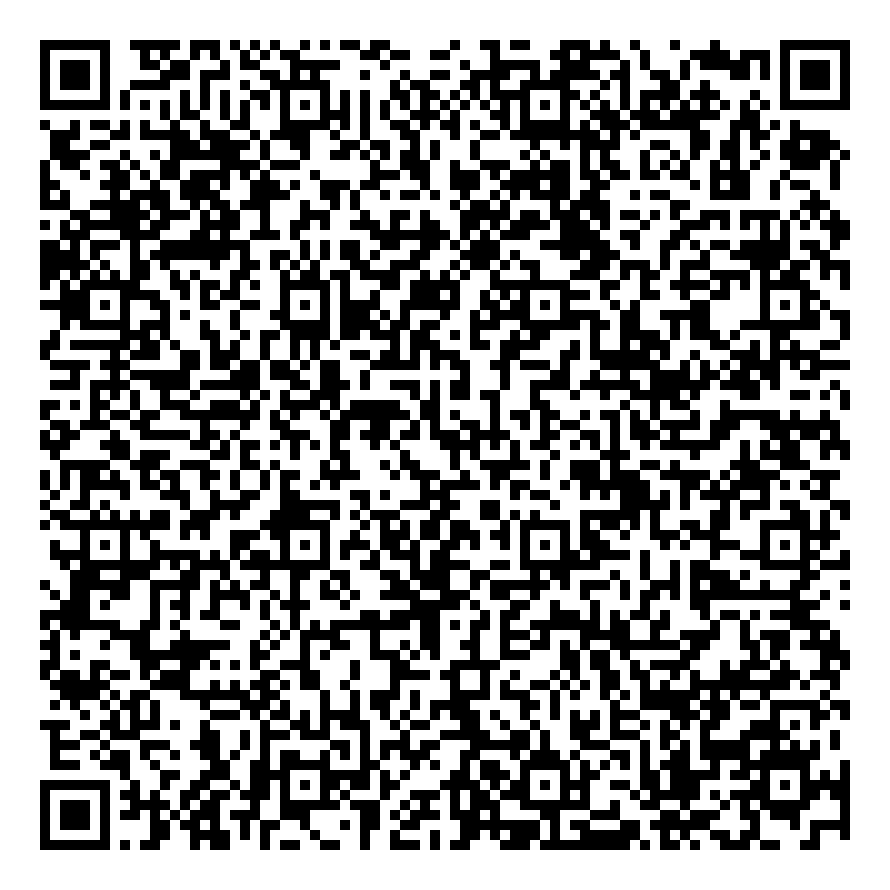

In [30]:
cbor_bytes = cbor2.dumps(payload)
sign1_msg.payload = cbor_bytes
tampered = sign1_msg.encode(sign=False)

compress = zlib.compress(tampered)
new_b45 = base45.b45encode(compress)
print(len(new_b45))

qrcode.make(new_b45)